# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Isi Nama Kalian | Isi NRP Kalian |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv('insurance.csv')
df.shape


(1338, 7)

In [3]:
# Tampilkan beberapa baris pertama dataset.
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Tampilkan informasi dataset.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Periksa missing value.
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
for col in ['sex', 'smoker', 'region']:
    print(col)
    print(df[col].value_counts())
    print()


sex
sex
male      676
female    662
Name: count, dtype: int64

smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


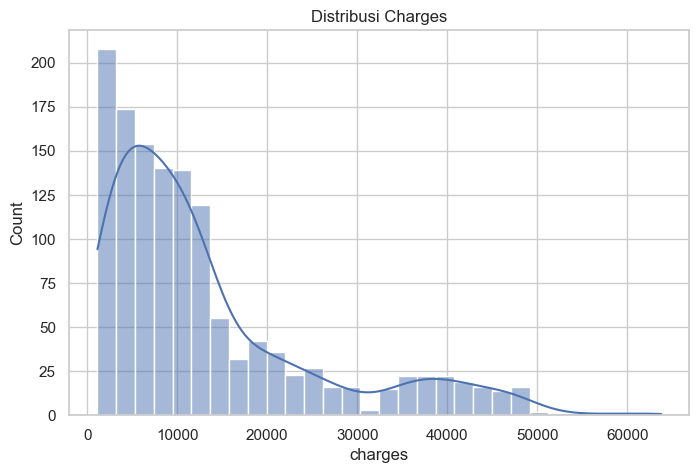

In [8]:
# Distribusi target (charges). Terlihat right-skewed, ada beberapa biaya yang sangat besar.
sns.histplot(df['charges'], kde=True)
plt.title('Distribusi Charges')
plt.xlabel('charges')
plt.show()


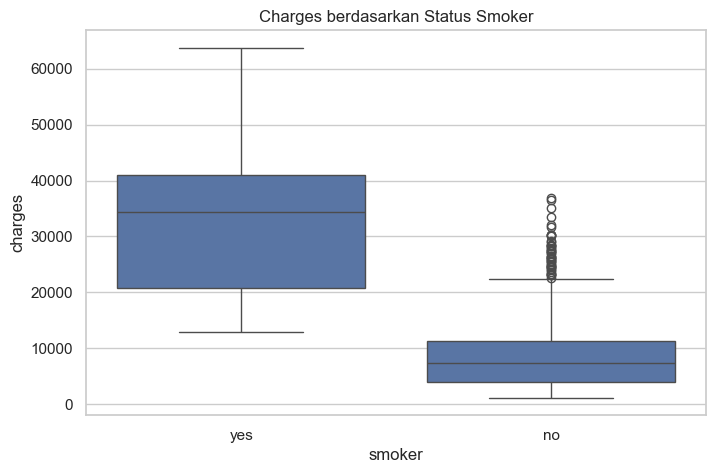

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


In [9]:
# Perbandingan charges perokok vs bukan perokok. Perokok rata-rata jauh lebih mahal.
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges berdasarkan Status Smoker')
plt.show()
print(df.groupby('smoker')['charges'].mean())


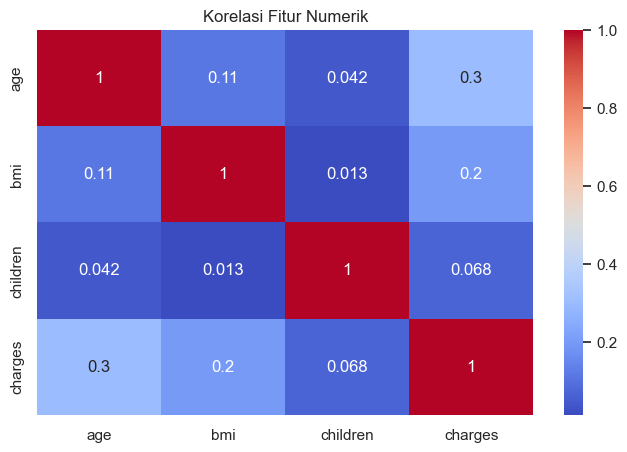

In [10]:
# Korelasi antar fitur numerik.
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()


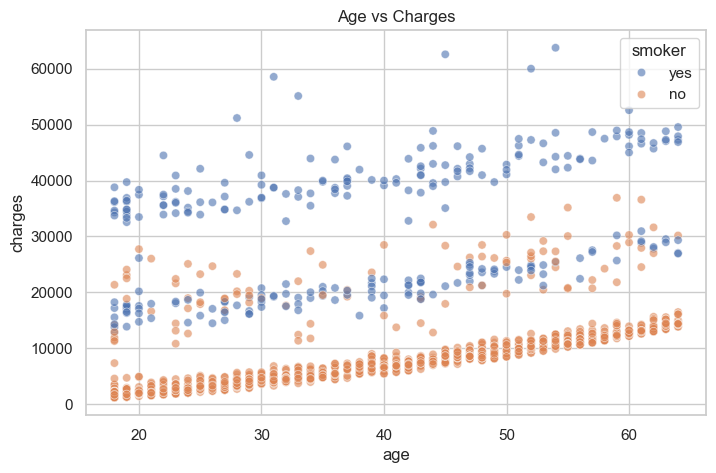

In [11]:
# Scatter umur vs charges, dibedakan berdasarkan smoker.
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs Charges')
plt.show()


# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [12]:
# Pisahkan fitur (X) dan target (y).
X = df.drop(columns=['charges'])
y = df['charges']


In [13]:
# Identifikasi kolom numerik dan kategorikal.
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']
print('Numerik:', num_cols)
print('Kategorikal:', cat_cols)


Numerik: ['age', 'bmi', 'children']
Kategorikal: ['sex', 'smoker', 'region']


In [14]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (1070, 6) Test: (268, 6)


In [15]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
# Ada dua versi: dengan scaling (untuk model linear & SVR) dan tanpa scaling (untuk tree).
pre_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pre_unscaled = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [16]:
# Inisialisasi dan latih Linear Regression.
lin_reg = Pipeline([
    ('preprocess', pre_scaled),
    ('model', LinearRegression())
])
lin_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [17]:
# Lakukan prediksi pada test set.
y_pred_lin = lin_reg.predict(X_test)


## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [18]:
# Buat fitur polynomial dan latih model.
# Saya coba degree 2 dan 3, ternyata degree 2 hasilnya paling bagus
# (degree 3 sedikit turun, kemungkinan mulai overfit).
poly_reg = Pipeline([
    ('preprocess', pre_scaled),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
poly_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [19]:
# Lakukan prediksi pada test set.
y_pred_poly = poly_reg.predict(X_test)


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [20]:
# Inisialisasi dan latih Ridge Regression.
# Saya coba alpha 0.1, 1, 10, 100. Hasilnya mirip-mirip,
# alpha=1.0 dipakai karena paling standar dan stabil.
ridge_reg = Pipeline([
    ('preprocess', pre_scaled),
    ('model', Ridge(alpha=1.0))
])
ridge_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Ridge())])

In [21]:
# Lakukan prediksi pada test set.
y_pred_ridge = ridge_reg.predict(X_test)


## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [22]:
# Inisialisasi dan latih Lasso Regression.
# Sama kayak Ridge, coba beberapa alpha dan ambil alpha=1.0.
lasso_reg = Pipeline([
    ('preprocess', pre_scaled),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])
lasso_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Lasso(max_iter=10000))])

In [23]:
# Lakukan prediksi pada test set.
y_pred_lasso = lasso_reg.predict(X_test)


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [24]:
# Inisialisasi dan latih Decision Tree Regressor.
# Tanpa max_depth pohonnya overfit (R2 train tinggi tapi test jelek),
# jadi dibatasi max_depth=5 biar lebih general.
tree_reg = Pipeline([
    ('preprocess', pre_unscaled),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])
tree_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DecisionTreeRegressor(max_depth=5, random_state=42))])

In [25]:
# Lakukan prediksi pada test set.
y_pred_tree = tree_reg.predict(X_test)


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [26]:
# Inisialisasi dan latih SVR.
# SVR ternyata sensitif banget sama parameter C. Dengan C kecil (1, 10)
# hasilnya jelek banget, jadi dipakai C=100 dengan kernel rbf.
svr_reg = Pipeline([
    ('preprocess', pre_scaled),
    ('model', SVR(kernel='rbf', C=100.0))
])
svr_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', SVR(C=100.0))])

In [27]:
# Lakukan prediksi pada test set.
y_pred_svr = svr_reg.predict(X_test)


# 4. Evaluasi Model

In [28]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
preds = {
    'Linear Regression': y_pred_lin,
    'Polynomial Regression': y_pred_poly,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_tree,
    'SVR': y_pred_svr,
}

rows = []
for nama, yp in preds.items():
    mse = mean_squared_error(y_test, yp)
    rows.append({
        'Model': nama,
        'MAE': mean_absolute_error(y_test, yp),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, yp)
    })

hasil = pd.DataFrame(rows).sort_values('R2', ascending=False)
hasil


,Model,MAE,MSE,RMSE,R2
1,Polynomial Regression,2729.500134,2.071281e+07,4551.132385,0.866583
4,Decision Tree,2911.160050,2.585779e+07,5085.055758,0.833443
0,Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
3,Lasso Regression,4182.081076,3.360584e+07,5797.054261,0.783536
2,Ridge Regression,4186.913072,3.362027e+07,5798.298795,0.783443
5,SVR,5967.493094,1.339913e+08,11575.461958,0.136925


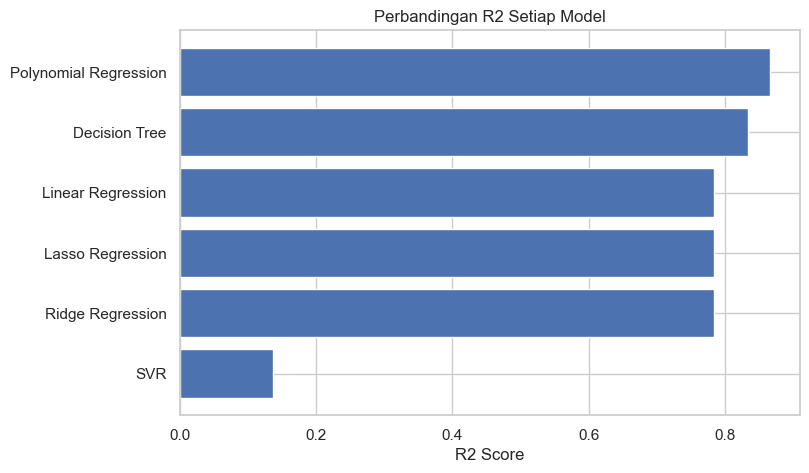

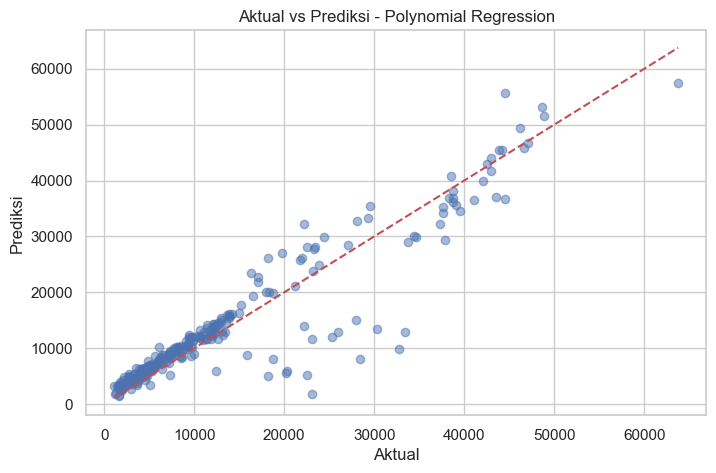

In [29]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
# Bar chart R2 biar gampang bandingin.
plt.figure()
plt.barh(hasil['Model'], hasil['R2'])
plt.xlabel('R2 Score')
plt.title('Perbandingan R2 Setiap Model')
plt.gca().invert_yaxis()
plt.show()

# Scatter aktual vs prediksi untuk model terbaik (Polynomial).
plt.figure()
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.title('Aktual vs Prediksi - Polynomial Regression')
plt.show()


# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


Dari tabel perbandingan di atas, Polynomial Regression (degree 2) jadi model yang paling bagus dengan R2 sekitar 0.87 dan RMSE paling kecil sekitar 4550. Artinya hubungan antara fitur dan charges itu ternyata nggak murni linear, ada interaksi antar fitur yang berhasil ditangkap sama fitur polynomial. Waktu saya coba degree 3 hasilnya malah sedikit turun, jadi kayaknya mulai overfit, makanya degree 2 yang dipakai.

Linear, Ridge, dan Lasso hasilnya mirip banget (R2 sekitar 0.78). Ini wajar karena datanya nggak ada multikolinearitas yang parah dan jumlah fiturnya juga dikit, jadi regularisasi L1/L2 nggak terlalu ngaruh. Waktu coba ganti-ganti alpha (0.1 sampai 100) hasilnya hampir sama, cuma kalau alpha kegedean (100) performanya malah turun karena modelnya jadi terlalu sederhana.

Decision Tree (max_depth=5) lumayan bagus dengan R2 sekitar 0.83, kedua terbaik setelah polynomial. Tanpa dibatasi max_depth pohonnya overfit, R2 test-nya malah turun ke sekitar 0.70, jadi pembatasan depth penting banget. Tree juga nggak butuh scaling karena cara kerjanya cuma bagi-bagi nilai fitur pakai threshold.

SVR jadi yang paling jelek (R2 sekitar 0.14). Model ini sensitif banget sama parameter dan scaling, waktu pakai C kecil hasilnya bahkan negatif R2-nya. Setelah scaling fitur dan C-nya digedein ke 100 hasilnya membaik tapi tetap jauh di bawah model lain. Kemungkinan karena target (charges) skalanya besar dan distribusinya skewed, jadi SVR susah nentuin epsilon dan hyperplane yang pas.

Pengaruh preprocessing: OneHotEncoder penting karena ada 3 fitur kategorikal (sex, smoker, region), dan smoker ternyata fitur yang paling ngaruh (rata-rata charges perokok hampir 4x lipat). Scaling (StandardScaler) wajib buat model berbasis jarak/gradien kayak SVR dan ngebantu Ridge/Lasso, tapi nggak ngaruh ke Decision Tree.


# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


Kesimpulannya, urutan model dari yang terbaik adalah Polynomial Regression, Decision Tree, lalu Linear/Ridge/Lasso yang hasilnya setara, dan SVR paling terakhir. Jadi buat dataset insurance ini, model yang bisa menangkap hubungan non-linear paling cocok.

Saran buat eksperimen lanjutan:
1. Coba transformasi target (misal log charges) karena distribusinya skewed, mungkin semua model jadi lebih bagus.
2. Tambah fitur baru kayak interaksi smoker*bmi atau kelompok umur.
3. Coba ensemble kayak Random Forest atau Gradient Boosting yang biasanya lebih kuat dari single tree.
4. Tuning SVR lebih lanjut (grid search C, gamma, epsilon) atau pakai target scaling.
5. Pakai cross-validation biar hasil evaluasinya lebih stabil dan nggak tergantung satu split aja.
